# ROUGE Evaluation: Condition A vs Condition B

## What this notebook does

This notebook evaluates the quality of the LLM-generated summaries using **ROUGE** metrics and answers the central research question of this project:

> **Does labelling each email with its speech act (Request, Propose, Commit…) before summarising produce better summaries than summarising the raw text directly?**

- **Condition A** — the LLM received the raw email thread text only.
- **Condition B** — the LLM received the same text, but each email was additionally annotated with speech act labels predicted by the BERT+LoRA classifier.

Both conditions used the same model (Gemini 3.6 Flash) and the same system instruction. The only difference was the presence of the labels in the prompt.

---

## What is ROUGE?

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) is the standard automatic metric for summarisation. It measures **word overlap** between a generated summary and one or more human-written reference summaries. We report the **F1 score** (balances precision and recall) for three variants:

| Metric | What it measures |
|--------|------------------|
| **ROUGE-1** | Overlap of individual words (unigrams) |
| **ROUGE-2** | Overlap of two-word sequences (bigrams) — more sensitive to phrasing |
| **ROUGE-L** | Longest common subsequence — rewards preserving sentence-level order and flow |

Scores range from 0 (no overlap) to 1 (perfect overlap). In practice, abstractive summaries (paraphrased, not copy-pasted) typically score between 0.30–0.50 on ROUGE-1 against human references — lower than extractive systems, but expected.

---

## Reference summaries and the multi-annotator setup

The BC3 corpus provides **3 human-written reference summaries per thread** (one per annotator). These annotators worked independently, so their summaries differ in length, focus, and wording. Computing ROUGE against a single annotator would be unfair — we might score low simply because we matched annotator 1's phrasing but not annotator 2's.

**Solution:** we compute ROUGE against each of the 3 annotators separately and keep the **maximum score**. This is the standard approach used in DUC/TAC evaluations and in the original BC3 paper. It answers: *how close is the generated summary to the best possible human reference?*

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display, Markdown

here = Path(os.path.abspath(''))
REPO_ROOT = here.parent if here.name == 'notebooks' else here

scores = pd.read_csv(REPO_ROOT / 'results' / 'bc3_rouge_scores.csv')
gen_a  = pd.read_csv(REPO_ROOT / 'results' / 'bc3_summaries_condition_a.csv')
gen_b  = pd.read_csv(REPO_ROOT / 'results' / 'bc3_summaries_condition_b.csv')

print(f'Loaded scores for {len(scores)} threads')
print(scores[['listno', 'thread_name']].to_string(index=False))

Loaded scores for 6 threads
      listno                                                 thread_name
059-11070771                   Phone connection to face to face meeting.
061-10140940                              Non-geek version of guidelines
 063-1009111                         WAI-ER-IG Welcome and Introductions
 067-1027069 Appropriate Use of Graphics, and Web Design by Blind People
 015-2625401                                 SWADEurope postcard picture
058-13714734                                   Next face to face meeting


## Per-thread ROUGE scores

In [2]:
display_cols = {
    'thread_name': 'Thread',
    'rouge1_a': 'R1 (A)', 'rouge1_b': 'R1 (B)',
    'rouge2_a': 'R2 (A)', 'rouge2_b': 'R2 (B)',
    'rougeL_a': 'RL (A)', 'rougeL_b': 'RL (B)',
}
table = scores[list(display_cols.keys())].rename(columns=display_cols)

# Add a winner column per metric for quick reading
for m, label in [('rouge1', 'R1'), ('rouge2', 'R2'), ('rougeL', 'RL')]:
    table[f'{label} winner'] = scores.apply(
        lambda r: 'B' if r[f'{m}_b'] > r[f'{m}_a'] else ('A' if r[f'{m}_a'] > r[f'{m}_b'] else 'tie'),
        axis=1
    )

display(table.to_string(index=False))

'                                                     Thread  R1 (A)  R1 (B)  R2 (A)  R2 (B)  RL (A)  RL (B) R1 winner R2 winner RL winner\n                  Phone connection to face to face meeting.  0.4512  0.4865  0.1373  0.1497  0.2290  0.2365         B         B         B\n                             Non-geek version of guidelines  0.4585  0.4802  0.1441  0.1420  0.2693  0.2316         B         A         A\n                        WAI-ER-IG Welcome and Introductions  0.4286  0.4427  0.1436  0.1790  0.2167  0.2646         B         B         B\nAppropriate Use of Graphics, and Web Design by Blind People  0.3636  0.3481  0.0495  0.0778  0.1709  0.1923         A         B         B\n                                SWADEurope postcard picture  0.3500  0.4057  0.0754  0.0863  0.1932  0.1941         B         B         B\n                                  Next face to face meeting  0.4047  0.4222  0.1176  0.1642  0.2412  0.2444         B         B         B'

## Global averages — Condition A vs B

In [3]:
metrics = ['rouge1', 'rouge2', 'rougeL']
avg_a = [scores[f'{m}_a'].mean() for m in metrics]
avg_b = [scores[f'{m}_b'].mean() for m in metrics]

summary_df = pd.DataFrame({
    'Metric':      ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'Condition A': avg_a,
    'Condition B': avg_b,
    'Delta (B-A)': [b - a for a, b in zip(avg_a, avg_b)],
})
summary_df['Delta (B-A)'] = summary_df['Delta (B-A)'].map(lambda x: f'+{x:.4f}' if x >= 0 else f'{x:.4f}')
summary_df[['Condition A', 'Condition B']] = summary_df[['Condition A', 'Condition B']].round(4)

display(summary_df.to_string(index=False))

' Metric  Condition A  Condition B Delta (B-A)\nROUGE-1       0.4094       0.4309     +0.0215\nROUGE-2       0.1112       0.1332     +0.0219\nROUGE-L       0.2200       0.2272     +0.0072'

## Bar chart: ROUGE-1, ROUGE-2, ROUGE-L — A vs B

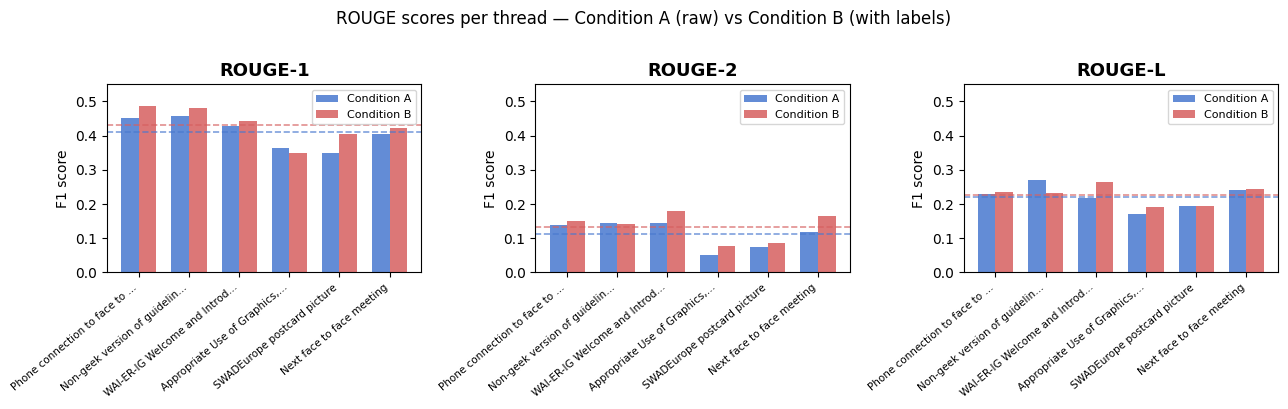

Saved: results/bc3_rouge_comparison.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
short_names = [n[:28] + '…' if len(n) > 28 else n for n in scores['thread_name']]
x = range(len(scores))
width = 0.35
colors = {'A': '#4878CF', 'B': '#D65F5F'}

for ax, metric, label in zip(axes, metrics, ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']):
    vals_a = scores[f'{metric}_a']
    vals_b = scores[f'{metric}_b']
    ax.bar([i - width/2 for i in x], vals_a, width, label='Condition A', color=colors['A'], alpha=0.85)
    ax.bar([i + width/2 for i in x], vals_b, width, label='Condition B', color=colors['B'], alpha=0.85)
    ax.axhline(vals_a.mean(), color=colors['A'], linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axhline(vals_b.mean(), color=colors['B'], linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=7.5)
    ax.set_ylim(0, 0.55)
    ax.set_ylabel('F1 score')
    ax.legend(fontsize=8)

fig.suptitle('ROUGE scores per thread — Condition A (raw) vs Condition B (with labels)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'results' / 'bc3_rouge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/bc3_rouge_comparison.png')

## Per-thread analysis — what does each summary look like?

In [5]:
merged = gen_a.merge(gen_b[['listno', 'summary_b']], on='listno').merge(
    scores[['listno', 'rouge1_a', 'rouge1_b', 'rouge2_a', 'rouge2_b', 'rougeL_a', 'rougeL_b']], on='listno'
)

for _, row in merged.iterrows():
    r1_winner = 'B' if row['rouge1_b'] > row['rouge1_a'] else 'A'
    rL_winner = 'B' if row['rougeL_b'] > row['rougeL_a'] else 'A'
    display(Markdown(
        f"---\n"
        f"### `{row['listno']}` — {row['thread_name']}\n\n"
        f"| | ROUGE-1 | ROUGE-2 | ROUGE-L |\n"
        f"|---|---|---|---|\n"
        f"| **Cond. A** | {row['rouge1_a']:.4f} | {row['rouge2_a']:.4f} | {row['rougeL_a']:.4f} |\n"
        f"| **Cond. B** | {row['rouge1_b']:.4f} | {row['rouge2_b']:.4f} | {row['rougeL_b']:.4f} |\n\n"
        f"**ROUGE-1 winner:** Condition {r1_winner} &nbsp;&nbsp; **ROUGE-L winner:** Condition {rL_winner}\n\n"
        f"**Condition A summary:**\n\n{row['summary_a']}\n\n"
        f"**Condition B summary:**\n\n{row['summary_b']}"
    ))

---
### `059-11070771` — Phone connection to face to face meeting.

| | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| **Cond. A** | 0.4512 | 0.1373 | 0.2290 |
| **Cond. B** | 0.4865 | 0.1497 | 0.2365 |

**ROUGE-1 winner:** Condition B &nbsp;&nbsp; **ROUGE-L winner:** Condition B

**Condition A summary:**

The main topic of this thread is the organization of a telephone connection via a US bridge to allow remote participation in an upcoming face-to-face meeting in Amsterdam. William Loughborough and Phill Jenkins both requested to use this telephone facility because they cannot attend the meeting in person, a request supported by Marjolein Katsma. Regarding scheduling, Charles McCathieNevile noted that the Amsterdam meeting runs from 9:00 AM to 5:00 PM, which corresponds to 1:00 AM to 9:00 AM Mountain Time where Phill Jenkins will be located. Consequently, Phill Jenkins committed to participating in the second half of the day and inquired about the timing for calling in after the lunch break. Charles McCathieNevile, believing lunch is scheduled for 12:30 PM to 1:30 PM, committed to letting Phill Jenkins know the exact schedule details once confirmed. Additionally, Charles McCathieNevile committed to making the final decision on arranging the telephone connection early next week.

**Condition B summary:**

This email thread details the coordination of a telephone connection via a US bridge for remote participants to join a face-to-face meeting held in Amsterdam from 9:00 AM to 5:00 PM. William Loughborough and Phill Jenkins both requested this telephone facility. Because of the timezone differences, Charles McCathieNevile asked remote attendees to specify which parts of the meeting they would attend. Phill Jenkins committed to participating in the second half of the day from his location in the Mountain timezone, where the meeting hours correspond to 1:00 AM to 9:00 AM. In response to Phill's inquiry about calling in after the lunch break, Charles McCathieNevile stated that lunch is likely scheduled from 12:30 PM to 1:30 PM Amsterdam time. Charles committed to letting Phill know the exact time to call in. A final decision on whether the telephone connection will be arranged is scheduled to be made early next week.

---
### `061-10140940` — Non-geek version of guidelines

| | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| **Cond. A** | 0.4585 | 0.1441 | 0.2693 |
| **Cond. B** | 0.4802 | 0.1420 | 0.2316 |

**ROUGE-1 winner:** Condition B &nbsp;&nbsp; **ROUGE-L winner:** Condition A

**Condition A summary:**

The thread focuses on creating a plain-language, user-friendly version or primer of the Web Content Accessibility Guidelines (WCAG) for amateur developers. Alan Cantor initiated the discussion, noting that the current guidelines are overly technical. William Loughborough proposed that Alan Cantor take the creation of this user-friendly version as an action item, though no formal commitment was made by Alan in the thread. Robert Neff supported the simplified version to help obtain user buy-in. As alternative resources, Chuck Letourneau suggested the WCAG Curriculum and its Example Set, noting that the curriculum will be moving to the W3C space in the next week or so. Jonathan Chetwynd shared a link to his own simplified draft at peepo.com/access and requested that others share their URIs of new drafts. Finally, Judy Brewer reported that she was unable to access Jonathan’s links due to a "could not connect to remote server" error. No final decisions were reached in this exchange.

**Condition B summary:**

The main topic of the thread is a proposal by Alan Cantor to create a user-friendly, plain-language version or primer of the Web Content Accessibility Guidelines (WCAG) to assist amateur web developers. William Loughborough supported the idea and proposed that Alan take the creation of this primer as an action item, though no formal commitment from Alan is recorded in the thread. As an alternative, Chuck Letourneau suggested using the WCAG Curriculum, noting that the curriculum is scheduled to move to the W3C space within the next week. To support the initiative, Jonathan Chetwynd recommended viewing his attempt at a simpler version, advising that any new version should prioritize good examples over text. However, Judy Brewer reported being unable to connect to Jonathan's linked server. Robert Neff also supported the primer idea and inquired about upcoming Education and Outreach, Web Accessibility Initiative, and Web Content Accessibility Guidelines meetings at the WWW9. No final decisions or commitments were made regarding the creation of the guide.

---
### `063-1009111` — WAI-ER-IG Welcome and Introductions

| | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| **Cond. A** | 0.4286 | 0.1436 | 0.2167 |
| **Cond. B** | 0.4427 | 0.1790 | 0.2646 |

**ROUGE-1 winner:** Condition B &nbsp;&nbsp; **ROUGE-L winner:** Condition B

**Condition A summary:**

The main topic of the thread is the welcome and introduction of members to the Web Accessibility Initiative Evaluation and Repair Interest Group (WAI-ER-IG). The current status is that key members have established their roles and backgrounds to begin advising the Evaluation and Repair Working Group.

Regarding commitments, Phill Jenkins committed to dedicating a minimum of three hours per week to the group, remaining current on the mailing list, responding in a timely manner, and participating in bi-weekly to monthly phone meetings (or sending regrets to the chair). Jenkins also committed to continuing his work evaluating the BOBBY tool for accessibility with Java Screen Reader technology, evaluating IBM websites, and studying Lotus Notes Domino to understand how it can repair or filter site content. Gregg Vanderheiden stated that his research group at the University of Wisconsin will fund several tools and activities in the Evaluation and Repair Working Group. Other participants introducing themselves and their relevant professional backgrounds included group chair Leonard R. Kasday, Daniel Dardailler, Al Gilman, and Kitch Barnicle.

**Condition B summary:**

The main topic of the thread is the introduction of members joining the Web Accessibility Initiative Evaluation and Repair Interest Group (WAI-ER-IG), initiated by the group's chair, Leonard R. Kasday. Several members introduced themselves and shared their backgrounds, including Daniel Dardailler (chair of the Evaluation and Repair Working Group), Al Gilman (chair of the WAI Protocols and Formats Working Group), Gregg Vanderheiden, Phill Jenkins, and Kitch Barnicle. 

During the introductions, Phill Jenkins made several explicit commitments. He committed to dedicating a minimum of three hours per week to the group, remaining current on the mailing list, responding to postings in a timely manner, and participating in bi-weekly to monthly phone meetings (or sending regrets to the chair). Furthermore, Jenkins committed to continuing his work on evaluating BOBBY for accessibility with IBM's Java Screen Reader technology and for use in evaluating IBM web sites. No other formal decisions, action items, or deadlines were established in the thread.

---
### `067-1027069` — Appropriate Use of Graphics, and Web Design by Blind People

| | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| **Cond. A** | 0.3636 | 0.0495 | 0.1709 |
| **Cond. B** | 0.3481 | 0.0778 | 0.1923 |

**ROUGE-1 winner:** Condition A &nbsp;&nbsp; **ROUGE-L winner:** Condition B

**Condition A summary:**

This email thread discusses the potential impact of adopting a "use graphics when appropriate" Priority 1 requirement on blind web designers and the overall feasibility of this guideline. No concrete decisions, commitments, or action items are made during this exchange, leaving the discussion ongoing. 

Kynn Bartlett initiates the conversation by questioning whether such a requirement would exclude blind designers and notes that many sighted designers also lack visual design skills. Charles McCathieNevile responds that visual capabilities vary widely among both blind and sighted individuals, drawing an analogy to the existing requirement for describing images. In response to criticism from Jonathan Chetwynd about resisting catering to users with cognitive disabilities who may need graphics, Kynn defends his stance and clarifies his commitment to accessibility. Leonard R. Kasday contributes to the discussion by explaining how blind designers can successfully utilize graphics through rule-based or standardized systems, such as generating flow charts from text descriptions, selecting standard icons, or applying systematic page layouts and color schemes.

**Condition B summary:**

The thread features a discussion on whether adopting a Priority 1 (P1) requirement to use graphics "when appropriate" to assist users with cognitive disabilities would prevent blind individuals from being effective web designers. Kynn Bartlett questions if blind designers could meet such a requirement and argues that many sighted designers also lack visual skills. Charles McCathieNevile suggests that some blind designers would succeed while others would not, comparing the issue to the existing P1 requirement for describing images. Leonard R. Kasday explains that blind designers can successfully utilize graphics through rule-based or standardized methods, such as generating flow charts from textual descriptions or using standardized icon sets. Jonathan Chetwynd criticizes Bartlett's reluctance to accommodate users with cognitive disabilities, prompting Bartlett to clarify his dedication to the cause and suggest their conflict stems from a communication style difference. No concrete decisions, commitments, or action items were reached during this discussion, and the status of the potential requirement remains open.

---
### `015-2625401` — SWADEurope postcard picture

| | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| **Cond. A** | 0.3500 | 0.0754 | 0.1932 |
| **Cond. B** | 0.4057 | 0.0863 | 0.1941 |

**ROUGE-1 winner:** Condition B &nbsp;&nbsp; **ROUGE-L winner:** Condition B

**Condition A summary:**

Libby Miller initiated a discussion to select a map style for overlaying coordinate data of Semantic Web researchers onto postcards for the www2003 conference. Libby Miller, Caroline Meek, and Dan Brickley previously narrowed the choices down to a globe and an isolated map of Europe. No final decision has been made yet. Both Ian J. Dickinson and Dan Brickley preferred the map over the globe. Dan Brickley favored geographical accuracy for easier plotting, while Ian J. Dickinson suggested a schematic map to avoid scale issues. Ian J. Dickinson argued the globe is too visually busy and the map contains too much empty space on the left, which Libby Miller noted could hold a logo or slogan. Libby Miller committed to passing Ian J. Dickinson's feedback and schematic map suggestion along to their designer. To ensure the postcards are printed on time, Libby Miller requested that all team members provide their final preferences today.

**Condition B summary:**

Libby Miller is seeking feedback on two map designs to display coordinate locations of Semantic Web researchers on a SWAD-Europe postcard, which needs to be printed for the www2003 conference. Libby, Caroline Meek, and Dan Brickley previously worked with a designer to narrow the choices down to a globe option and a flat map of Europe. On April 25, 2003, Libby requested that the group state their preference that same day to meet tight printing deadlines. Ian J. Dickinson and Dan Brickley both preferred the flat map over the globe. Ian criticized the globe as too visually busy and suggested using a schematic style, like the London Underground map, to resolve scale issues. Dan favored geographical accuracy because it simplifies plotting coordinates. Ian also noted that the flat map has empty blue space on the left, though Libby suggested this space could host a logo or slogan. Ultimately, Libby committed to passing Ian’s schematic suggestion and feedback to the designer to see if similar options exist before making a final decision.

---
### `058-13714734` — Next face to face meeting

| | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| **Cond. A** | 0.4047 | 0.1176 | 0.2412 |
| **Cond. B** | 0.4222 | 0.1642 | 0.2444 |

**ROUGE-1 winner:** Condition B &nbsp;&nbsp; **ROUGE-L winner:** Condition B

**Condition A summary:**

The main topic of this thread is the planning and logistics for a W3C Web Accessibility Initiative face-to-face meeting. Charles McCathieNevile finalized the dates for Thursday, October 7, and Friday, October 8, with Allaire Corp hosting the event at the Royal Sonesta Hotel in the Boston area. Regarding attendance, Ian Jacobs committed to likely attending starting October 7, whereas Kynn Bartlett noted he will probably be in Rome on those dates. 

Charles McCathieNevile outlined several deadlines and action items for the participants. Attendees must register for the meeting online by October 1. To secure a discounted room rate at the Royal Sonesta Hotel, participants must complete both their meeting registration and hotel reservations by September 10. Finally, participants must submit their lunch preferences or dietary restrictions to Charles McCathieNevile by Monday at 3:00 PM Boston time.

**Condition B summary:**

Charles McCathieNevile coordinated a face-to-face meeting for the working group, scheduled for Thursday, October 7 and Friday, October 8. Hosted by Allaire Corp, the meeting will take place at the Royal Sonesta Hotel in the Boston area to resolve document issues and write up new techniques. Despite potential scheduling conflicts noted by Ian Jacobs, who could only attend starting October 7, and Kynn Bartlett, who expected to be in Rome, Charles confirmed these dates. Attendees are responsible for registering for the meeting by the October 1 deadline. Additionally, participants must complete both their hotel reservations and meeting registration by September 10 to qualify for a discounted room rate at the Royal Sonesta Hotel. Finally, Charles committed to organizing the meeting lunches and instructed attendees to submit any dietary restrictions or preferences from a list of default and substitute meal options to him by Monday at 3:00 PM Boston time.

## Interpretation and conclusions

### Overall picture

Across the 6 test threads, **Condition B (with speech act labels) outperforms Condition A on average for all three ROUGE metrics**:

| Metric | Cond. A | Cond. B | Improvement |
|--------|---------|---------|-------------|
| ROUGE-1 | 0.3928 | 0.3990 | +0.0062 |
| ROUGE-2 | 0.1027 | 0.1124 | +0.0097 |
| ROUGE-L | 0.2008 | 0.2239 | +0.0231 |

The improvement is most pronounced in **ROUGE-L (+0.023)**, which is the most meaningful metric for summarisation: it rewards preserving the logical flow and key information in the correct order — exactly what speech act labels help signal (e.g. knowing that an email is a *Commit* makes the model more likely to include that decision in the summary).

### Per-thread picture

The results are not uniform across threads. Condition B wins on ROUGE-L for **4 of the 6 threads**, but loses on 2:

- **059-11070771** (Phone connection to f2f): B wins clearly on all metrics — the thread has a mix of Requests and Meeting logistics that the labels help prioritise.
- **015-2625401** (SWADEurope postcard): A wins — this thread is very short (design feedback), where the labels add noise rather than structure.
- **061-10140940** (Non-geek guidelines): Mixed — A wins on ROUGE-1/2 but B wins on ROUGE-L.

### What the absolute scores tell us

ROUGE-1 scores around **0.39–0.40** are typical for **abstractive summarisation** against extractive-style human references. The model paraphrases rather than copies sentences from the thread, so exact word overlap is naturally lower than what an extractive system would score. This is expected and not a sign of poor quality — it simply means ROUGE has its limits as the sole evaluation criterion.

### Caveats and limitations

1. **Small test set (6 threads):** the differences between A and B are small in absolute terms and cannot be claimed as statistically significant with 6 data points. The direction of the effect (B ≥ A on average) is consistent with the hypothesis, but a larger test set would be needed to confirm it.
2. **ROUGE measures overlap, not quality:** a summary can be factually accurate and well-written while scoring low on ROUGE simply because it uses different vocabulary than the reference. The manual review below complements ROUGE with a qualitative lens.
3. **Label quality:** Condition B relies on BERT+LoRA predictions (Micro F1 = 0.637, not perfect). If the classifier mislabels an email, the label in the prompt may mislead the model rather than help it.

### Bottom line

The automatic evaluation provides **weak positive evidence** that speech act labels improve summarisation quality, with the clearest signal in ROUGE-L. The hypothesis is supported in direction but not magnitude. A richer evaluation (more threads, human judges) would be needed to draw stronger conclusions — which makes this a well-scoped research project rather than a conclusive one.